# Seq2seq 번역기
- Dataset: 한국어-영어 말뭉치
- Method:
  - 전처리
  - Model: Bahdanau attention-seq2seq
  - Train:
    - (1) Optimizer & Loss: Encoder-Decoder 구조를 정의
    - (2) train_step 구현: Loss를 계산한 후 반환하는 함수를 학습
    - (3) 훈련: 학습+시각화

## 세팅

In [26]:
import pandas
import torch
import matplotlib

print(pandas.__version__)
print(torch.__version__)
print(matplotlib.__version__)

2.3.0
2.7.1+cu118
3.10.3


In [5]:
# ! mkdir -p ~/work/s2s_translation #실습 데이터 폴더
!sudo apt update
!sudo apt-get install -y fonts-nanum #한국어 폰트
!pip install sentencepiece

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:2 http://archive.ubuntu.com/ubuntu noble InRelease [256 kB]
Get:3 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [3300 kB]
Get:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]m
Get:6 http://archive.ubuntu.com/ubuntu noble/universe amd64 Packages [19.3 MB]
Get:7 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1895 kB]
Get:8 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [34.8 kB]
Get:9 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1260 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble/main amd64 Packages [1808 kB]    
Get:11 http://archive.ubuntu.com/ubuntu noble/multiverse amd64 Packages [331 kB]
Get:12 http://archive.ubuntu.com/ubuntu noble/restricted amd64 Packages [117 kB]
Get:13 http://archive.ubuntu.com/ubunt

In [27]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


## 데이터셋

train 모델학습  
dev 학습 중 성능 확인  
test 최종 평가

In [28]:
import os
import re
import urllib.request # !! urlretrieve(): url로부터 데이터 다운로드, zip_ref.extractall(): 폴더 내 압축 파일 해제
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.7.1+cu118


### step 1. 데이터 다운로드

In [30]:
dataset_dir = os.path.expanduser("~/work/s2s_translation/datasets")
os.makedirs(dataset_dir, exist_ok=True)
'''
tar_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

# spa-eng 압축해제
data_folder = os.path.join(dataset_dir, "spa-eng")

if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(tar_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))
'''

#kor-eng 압축해제
data_folder = os.path.join(dataset_dir, "kor-eng")
'''
for file in os.listdir(dataset_dir):
    if file.endswith(".tar") or file.endswith(".tar.gz"):
        with tarfile.open(os.path.join(dataset_dir, file), "r:*") as tar:
            tar.extractall(data_folder)
'''
print("압축 해제 완료")

압축 해제 완료


In [31]:
data_folder = os.path.join(dataset_dir, "kor-eng")

train_ko = os.path.join(data_folder, "korean-english-park.train.ko")
train_en = os.path.join(data_folder, "korean-english-park.train.en")

In [32]:
test_ko = os.path.join(data_folder, "korean-english-park.test.ko")
test_en = os.path.join(data_folder, "korean-english-park.test.en")
dev_ko = os.path.join(data_folder, "korean-english-park.dev.ko")
dev_en = os.path.join(data_folder, "korean-english-park.dev.en")

### step 2. 데이터 정제
- pair 리스트 생성
- 중복 제거 -> cleaned_corpus에 저장
- 문장 정제 (특수문자 제거, 공백 정리) -> 한글 정규식 추가
- 영문 토큰화: start, end 토큰 추가 -> split() 함수 이용하여 토큰화
- 한글 토큰화: KoNLPy의 mecab 클래스 사용
- cleaned_corpus 중 토큰 길이 40 이하인 데이터만 선별하여 eng_corpus, kor_corpus 각각 구축

In [33]:
import pandas as pd
import os

# pair dataframe 생성
def load_to_dataframe(ko_path, en_path):
    with open(ko_path, "r", encoding="utf-8") as f:
        ko_lines = f.read().splitlines()
    with open(en_path, "r", encoding="utf-8") as f:
        en_lines = f.read().splitlines()
    
    # 두 파일의 줄 수가 맞는지 확인하는 것이 좋습니다.
    if len(ko_lines) != len(en_lines):
        print(f"⚠️ 경고: {os.path.basename(ko_path)}와 {os.path.basename(en_path)}의 데이터 개수가 다릅니다!")
        
    return pd.DataFrame({"kor": ko_lines, "eng": en_lines})

# 1. Train 데이터 (이미 경로 변수가 있다고 가정)
train_df = load_to_dataframe(train_ko, train_en)

# 2. Dev 데이터
dev_df = load_to_dataframe(dev_ko, dev_en)

# 3. Test 데이터
test_df = load_to_dataframe(test_ko, test_en)

# 확인
print(f"Train: {len(train_df)} | Dev: {len(dev_df)} | Test: {len(test_df)}")

Train: 94123 | Dev: 1000 | Test: 2000


In [49]:
import pandas as pd

def clean_dataframe(df, name="데이터셋"):
    print(f"--- {name} 정제 시작 ---")
    print(f"원본 데이터 길이: {len(df)}")
    
    # 1. 중복 제거 (set 활용)
    pairs = list(zip(df["kor"], df["eng"]))
    unique_pairs = list(set(pairs))
    
    # 2. 다시 데이터프레임으로 변환
    cleaned_df = pd.DataFrame(unique_pairs, columns=["kor", "eng"])
    
    # 3. 공백만 있는 데이터나 NaN 제거
    cleaned_df.dropna(inplace=True)
    cleaned_df = cleaned_df[cleaned_df["kor"].str.strip() != ""]
    cleaned_df = cleaned_df[cleaned_df["eng"].str.strip() != ""]
    
    print(f"정제 후 데이터 길이: {len(cleaned_df)}")
    print(f"제거된 중복 데이터 수: {len(df) - len(cleaned_df)}\n")
    
    return cleaned_df

# --- 모든 데이터셋에 적용 ---
cleaned_train = clean_dataframe(train_df, "Train")
cleaned_dev = clean_dataframe(dev_df, "Dev")
cleaned_test = clean_dataframe(test_df, "Test")

--- Train 정제 시작 ---
원본 데이터 길이: 94123
정제 후 데이터 길이: 78968
제거된 중복 데이터 수: 15155

--- Dev 정제 시작 ---
원본 데이터 길이: 1000
정제 후 데이터 길이: 1000
제거된 중복 데이터 수: 0

--- Test 정제 시작 ---
원본 데이터 길이: 2000
정제 후 데이터 길이: 1996
제거된 중복 데이터 수: 4



In [51]:
import re

def preprocess_sentence(sentence):
    # 1. 소문자 변환 및 양 끝 공백 제거
    sentence = sentence.lower().strip()

    # 2. 구두점 앞뒤에 공백 추가 (예: "hi!" -> "hi ! ")
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    
    # 3. 여러 개의 공백을 하나로 합침
    sentence = re.sub(r'[" "]+', " ", sentence)
    
    # 4. 영문, 한글, 주요 구두점 제외한 모든 문자 제거
    sentence = re.sub(r"[^a-zA-Z가-힣?.!,]+", " ", sentence)
    
    # 5. 최종 양 끝 공백 제거
    sentence = sentence.strip()

    return sentence

# Train 데이터는 학습 속도를 위해 30,000개로 슬라이싱
# 전처리 데이터셋 저장
train_data = cleaned_train.copy() 
train_data["eng"] = train_data["eng"].apply(preprocess_sentence)
train_data["kor"] = train_data["kor"].apply(preprocess_sentence)

validation_data = cleaned_dev.copy() 
validation_data["eng"] = validation_data["eng"].apply(preprocess_sentence)
validation_data["kor"] = validation_data["kor"].apply(preprocess_sentence)

test_data = cleaned_test.copy() 
test_data["eng"] = test_data["eng"].apply(preprocess_sentence)
test_data["kor"] = test_data["kor"].apply(preprocess_sentence)

print("전처리 완료!")
display(train_data.head())

전처리 완료!


,kor,eng
0,신원이 밝혀지지 않은 이 용의자들은 일 뉴델리서 탑승했으나 기차를 잘못 탔다며 열차...,"the suspects , whose identities were not known..."
1,팰런 사령관은 미군 중부사령부에 부임한지 년 만에 사임했다 .,william fallon resigned tuesday as chief of u ...
2,달러 약 만원 캠코더 플립은 기계치인 사람들에게 한 손에 잡을 수 있는 포켓 캠코더...,the flip has been a hit ever since it hit the ...
3,"보고서에따르면 , 보건 위생에 대한 연차 정부 지출 차이는 이 격차보다 더 심각하다 .",the difference in annual government expenditur...
4,"미군과 다국적군이 탈레반 반군 은신처로 의심되는 아프가니스탄 민가를 공습 , 무장세...",an investigation into u . s . led airstrikes t...


### Step 3. 토큰화 -> 파일 저장

In [16]:
!pip install python-mecab-ko
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.6/579.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 71.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [python-mecab-ko]dic]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 100.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [konlpy]2m2/3 [konlpy]


In [52]:
from mecab import MeCab
tokenizer = MeCab()

def tokenize_corpus(df, max_len=None):
    eng_out, kor_out = [], []
    
    for row in df.itertuples():
        # 1. 영문 토큰화 (<start>, <end> 추가)
        eng_sentence = f"<start> {row.eng} <end>"
        eng_tokens = eng_sentence.split()
        
        # 2. 한글 토큰화 (MeCab)
        kor_tokens = tokenizer.morphs(row.kor)
        
        # 3. 조건부 길이 필터링
        if max_len:
            # 학습 데이터용: 두 언어 모두 max_len 이하일 때만 통과
            if len(eng_tokens) <= max_len and len(kor_tokens) <= max_len:
                eng_out.append(eng_tokens)
                kor_out.append(kor_tokens)
        else:
            # 검증/테스트용: 길이 제한 없이 모두 통과
            eng_out.append(eng_tokens)
            kor_out.append(kor_tokens)
            
    return eng_out, kor_out

# --- 각각 적용 ---
# Train: 학습 효율을 위해 40 이하로 제한
train_eng_corpus, train_kor_corpus = tokenize_corpus(train_data, max_len=40)

# Dev/Test: 모델의 범용성 평가를 위해 모든 길이 수용
val_eng_corpus, val_kor_corpus = tokenize_corpus(validation_data)
test_eng_corpus, test_kor_corpus = tokenize_corpus(test_data)

print(f"✅ 토큰화 완료!")
print(f"Train: {len(train_eng_corpus)}개 (길이 40 제한)")
print(f"Val: {len(val_eng_corpus)}개 (제한 없음)")
print(f"Test: {len(test_eng_corpus)}개 (제한 없음)")

✅ 토큰화 완료!
Train: 62750개 (길이 40 제한)
Val: 1000개 (제한 없음)
Test: 1996개 (제한 없음)


In [53]:
import os

def save_corpus(eng_corpus, kor_corpus, prefix):
    # 파일명 설정 (예: train_eng_corpus.txt)
    eng_file = f"data/{prefix}_eng_corpus.txt"
    kor_file = f"data/{prefix}_kor_corpus.txt"
    
    # 영어 저장
    with open(eng_file, "w", encoding="utf-8") as f:
        for tokens in eng_corpus:
            f.write(" ".join(tokens) + "\n")
            
    # 한국어 저장
    with open(kor_file, "w", encoding="utf-8") as f:
        for tokens in kor_corpus:
            f.write(" ".join(tokens) + "\n")
            
    print(f"✅ {prefix} 파일 저장 완료: {eng_file}, {kor_file}")

# --- 실행 ---
save_corpus(train_eng_corpus, train_kor_corpus, "train")
save_corpus(val_eng_corpus, val_kor_corpus, "val")
save_corpus(test_eng_corpus, test_kor_corpus, "test")

✅ train 파일 저장 완료: data/train_eng_corpus.txt, data/train_kor_corpus.txt
✅ val 파일 저장 완료: data/val_eng_corpus.txt, data/val_kor_corpus.txt
✅ test 파일 저장 완료: data/test_eng_corpus.txt, data/test_kor_corpus.txt


### Step 3.2 Vocab

In [56]:
from collections import Counter

def analyze_vocab(corpus):
    counter = Counter()

    for sent in corpus:
        counter.update(sent)

    total_tokens = sum(counter.values())
    vocab_size = len(counter)

    print(f"Total tokens: {total_tokens}")
    print(f"Vocab size: {vocab_size}")

    # 빈도 기준 정렬
    sorted_vocab = counter.most_common()

    # coverage 계산
    cumulative = 0
    results = []

    for i, (word, freq) in enumerate(sorted_vocab, start=1):
        cumulative += freq
        coverage = cumulative / total_tokens

        # 특정 vocab size에서 coverage 확인
        if i in [1000, 2000, 3000, 5000, 10000, 20000]:
            results.append((i, coverage))

    print("\nCoverage by vocab size:")
    for v, c in results:
        print(f"Vocab {v:6d} → {c*100:.2f}%")

    return counter

In [57]:
print("English corpus")
eng_counter = analyze_vocab(train_eng_corpus)

print("\nKorean corpus")
kor_counter = analyze_vocab(train_kor_corpus)

English corpus
Total tokens: 1457310
Vocab size: 38370

Coverage by vocab size:
Vocab   1000 → 75.89%
Vocab   2000 → 83.04%
Vocab   3000 → 87.02%
Vocab   5000 → 91.30%
Vocab  10000 → 95.65%
Vocab  20000 → 98.43%

Korean corpus
Total tokens: 1538497
Vocab size: 43958

Coverage by vocab size:
Vocab   1000 → 75.83%
Vocab   2000 → 82.79%
Vocab   3000 → 86.52%
Vocab   5000 → 90.64%
Vocab  10000 → 94.99%
Vocab  20000 → 97.97%


In [58]:
vocab_size = 10000 # 전체의 95% 포함
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

#vocab, model 파일 생성
spm.SentencePieceTrainer.train(
    input = "data/train_kor_corpus.txt",
    model_prefix = "model/encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "data/train_eng_corpus.txt",
    model_prefix = "model/decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/train_kor_corpus.txt
  input_format: 
  model_prefix: model/encoder_spm
  model_type: UNIGRAM
  vocab_size: 10000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_different

In [59]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("model/encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("model/decoder_spm.model")

True

In [61]:
# 예시 샘플
eng_sample = train_df["eng"][2]
kor_sample = train_df["kor"][2]
print(eng_sample)
print(kor_sample)

# 예시 토큰화 - 인코더
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
print(enc_token)

# 예시 - 디코더
enc_decoding = encoder_tokenizer.decode(enc_token)
print(enc_decoding)

Like all optical mice, But it also doesn't need a desk.
그러나 이것은 또한 책상도 필요로 하지 않는다.
[1, 4, 3, 1549, 4160, 3855, 3543, 6675, 5284, 567, 5369, 9998, 4, 3, 1892, 1388, 3045, 3951, 129, 1852, 4496, 1752, 1288, 3, 1388, 7879, 432, 4261, 8433, 9999, 2]
 ⁇ ike all optical mice,  ⁇ ut it also doesn ⁇ t need a desk.


In [62]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer #한국어
        self.decoder_tokenizer = decoder_tokenizer #영어
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['kor'] #한국어 입력
        trg_text = self.data.iloc[idx]['eng'] #영어 출력

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # decoder 입력: <bos> + 영어 문장 + <eos>
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]

        # decoder 정답: 영어 문장 + <eos>
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # padding
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [63]:
#dataset이 df 하나일때
#train_ratio = 0.8  # 전체 길이의 80%
#train_data = train_df.sample(frac=train_ratio, random_state=42)  # 80% 훈련 데이터
#valid_data = train_df.drop(train_data.index)
#train_data.reset_index(drop=True, inplace=True)
#valid_data.reset_index(drop=True, inplace=True)

#train, dev, test dataset 따로있을때

MAX_LEN = 40
BATCH_SIZE = 64

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validation_data = TranslationDataset(validation_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
test_data = TranslationDataset(test_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [64]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 40]) torch.Size([64, 40]) torch.Size([64, 40])


## Step 4. 모델 설계

In [65]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [66]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [67]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [68]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [69]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [70]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)

model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [71]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(10000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=10000, bias=True)
  )
)


## Step 5. 훈련하기

### (1) Optimizer & Loss

In [72]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


### (2) train_step, eval_step 구현

In [73]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)
        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


In [74]:
# 검증 데이터로 loss 계산
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        # 모델의 입력 순서에 맞게 transpose 변환
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        outputs,_ = model(src, trg_input)
        
        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


### (3) 훈련

In [75]:
%%time

EPOCHS = 10

history = {
    "train_loss": [],
    "valid_loss": []
}

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 1234/1234 [04:45<00:00,  4.32it/s, loss=3.6] 


Epoch 1/10, Train Loss: 4.3052, Validation Loss: 3.7836


Epoch 2: 100%|██████████| 1234/1234 [04:44<00:00,  4.33it/s, loss=3.29]


Epoch 2/10, Train Loss: 3.3215, Validation Loss: 3.5367


Epoch 3: 100%|██████████| 1234/1234 [04:45<00:00,  4.32it/s, loss=2.89]


...

Epoch 8/10, Train Loss: 1.7136, Validation Loss: 4.0262


Epoch 9: 100%|██████████| 1234/1234 [04:44<00:00,  4.33it/s, loss=1.83]


Epoch 9/10, Train Loss: 1.6041, Validation Loss: 4.1379


Epoch 10: 100%|██████████| 1234/1234 [04:44<00:00,  4.34it/s, loss=1.69]


Epoch 10/10, Train Loss: 1.5142, Validation Loss: 4.2578
CPU times: user 44min 41s, sys: 3min 15s, total: 47min 56s
Wall time: 47min 42s


In [76]:
import torch
import json

#모델 저장
torch.save(model.state_dict(), "model/Seq2SeqAttention-2.pt")

#history 저장
with open("model/Seq2SeqAttention-history-2.json", "w") as f:
    json.dump(history, f)

## 평가하기

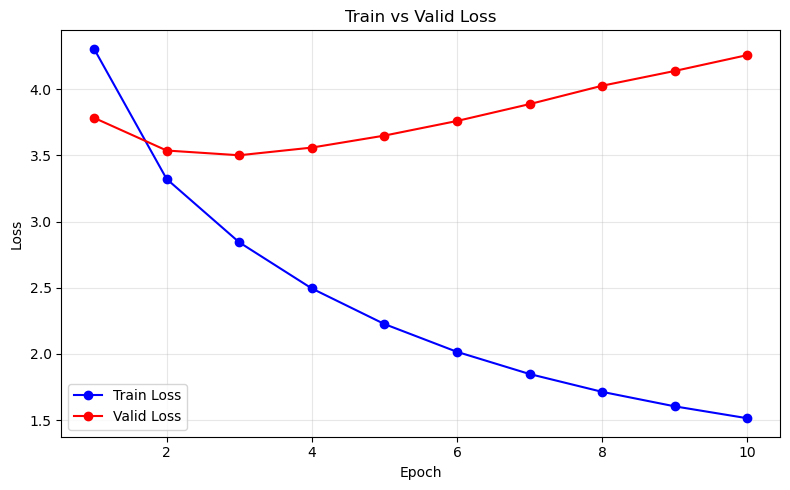

In [77]:
import json
import matplotlib.pyplot as plt

# history 불러오기
with open(os.path.join('model', 'Seq2SeqAttention-history-2.json')) as f:
    history = json.load(f)

# 시각화
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
plt.plot(epochs, history['valid_loss'],   'r-o', label='Valid Loss')
plt.title('Train vs Valid Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join('model', 'loss.png'), dpi=150)
plt.show()

In [25]:
#저장된 모델 불러오기

import torch
import json

# 모델 생성
model = Seq2SeqAttention(encoder, decoder, device).to(device)

# weight 로드
model.load_state_dict(
    torch.load("model/Seq2SeqAttention-1.pt", map_location=device)
)

model.eval()

# history 로드
with open("model/Seq2SeqAttention-history-1.json") as f:
    history = json.load(f)


NameError: name 'Seq2SeqAttention' is not defined

In [78]:
#학습 모델을 사용하여 번역하기(추론)
#번역결과, 입력 문장, attention matix가 출력됨
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    result = [decoder_tokenizer.decode([token.item()]) for token in outputs.argmax(2).squeeze(1)]

    if "<end>" in result:
        result = result[:result.index("<end>")]

    pred_ids = outputs.argmax(2).squeeze(1).tolist()

    # <end> 토큰 제거
    if 2 in pred_ids:   # eos_id = 2 인 경우
        pred_ids = pred_ids[:pred_ids.index(2)]

    # 전체 문장 decode
    pred_sentence = decoder_tokenizer.decode(pred_ids)
    # 🔧 문장 후처리 (detokenize)
    pred_sentence = re.sub(r"\s+([.,!?;:])", r"\1", pred_sentence)  # punctuation 앞 공백 제거
    pred_sentence = re.sub(r"\s+", " ", pred_sentence).strip()      # 중복 공백 제거

    return result, pred_sentence, sentence, attentions.squeeze(1).cpu().numpy()

In [79]:
# attention matrix -> heatmap 시각화
def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    fontdict = {'fontsize': 14}

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontproperties=fontprop, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontproperties=fontprop)

    plt.show()

In [80]:
#번역 실행 함수
#1) evaluate를 호출 -> result, sentence 출력 2) attention 입력받아 -> heatmap 출력
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=40):
    result, pred_sentence, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)
    result_sentence = " ".join(result)
    
    print('Input: %s' % (sentence))
    #print('Predicted translation: {}'.format(result))
    print('Predicted translation:', pred_sentence)

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

#### 정성적 관찰

In [81]:
test_ko = os.path.join(data_folder, "korean-english-park.test.ko")
test_en = os.path.join(data_folder, "korean-english-park.test.en") #전처리 후 데이터 불러오기

with open(test_ko, encoding="utf-8") as f:
    test_ko_lines = f.read().splitlines()

with open(test_en, encoding="utf-8") as f:
    test_en_lines = f.read().splitlines()

Target: Those involved in the discussions do take seriously the need to address concerns of law enforcement and national security.
Input: 토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을 진지하게 받아 들이고 있습니다 .
Predicted translation: debate watchers say they need to be concerned about the security law enforcement and national security law.


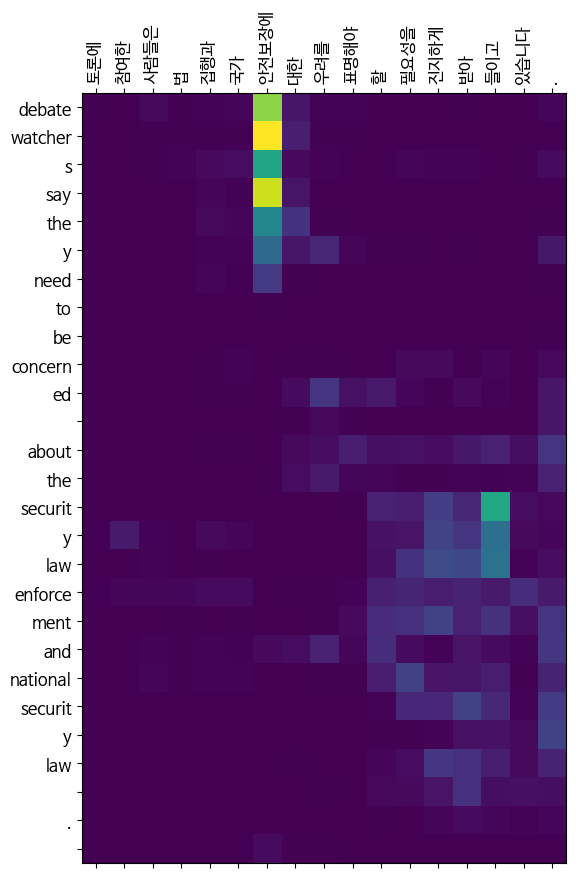

In [84]:
print("Target:", test_en_lines[0])
translate(test_ko_lines[0], model, encoder_tokenizer, decoder_tokenizer)

#### 정량적 평가 - BLEU
- 4-gram precision
- 어순 변화에 민감함

In [83]:
!pip uninstall -y numpy scipy scikit-learn nltk
!pip install --no-cache-dir --force-reinstall \
  numpy==1.26.4 \
  scipy==1.11.4 \
  scikit-learn==1.3.2 \
  nltk==3.9.1

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.11.4
Uninstalling scipy-1.11.4:
  Successfully uninstalled scipy-1.11.4
Found existing installation: scikit-learn 1.3.2
Uninstalling scikit-learn-1.3.2:
  Successfully uninstalled scikit-learn-1.3.2
Found existing installation: nltk 3.9.1
Uninstalling nltk-3.9.1:
  Successfully uninstalled nltk-3.9.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 196.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 275.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 244.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 436.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.0/802.0 kB 609.7 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
      Successfully uninstalled tqdm-4.67.3
  Atte

In [1]:
import numpy, scipy, sklearn, nltk
print(numpy.__version__)
print(scipy.__version__)
print(sklearn.__version__)
print(nltk.__version__)

1.26.4
1.11.4
1.3.2
3.9.1


In [2]:
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

reference = ["나는", "서울대학교", "3학년", "학생", "이다"]
candidate = ["나는", "서울대학교", "3학년", "학생"]

smooth = SmoothingFunction().method1

bleu = sentence_bleu([reference], candidate, smoothing_function=smooth)
print(bleu)

0.7788007830714049


In [3]:
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

reference = ["나는", "서울대학교", "3학년", "학생", "이다"]
candidate = ["나는", "3학년", "서울대학교", "학생", "이다"]

smooth = SmoothingFunction().method1

bleu = sentence_bleu([reference], candidate, smoothing_function=smooth)
print(bleu)

0.14287202148493997


#### 정량적 평가 - **BLEU + BERT_score**

In [86]:
!pip install -q sacrebleu bert-score

In [86]:
test_ko = os.path.join(data_folder, "korean-english-park.test.ko")
test_en = os.path.join(data_folder, "korean-english-park.test.en")

with open(test_ko, encoding="utf-8") as f:
    test_ko_lines = f.read().splitlines()

with open(test_en, encoding="utf-8") as f:
    test_en_lines = f.read().splitlines()

references = []
hypotheses = []
predicted_sentences = []

for ko, en in zip(test_ko_lines, test_en_lines):
    _, pred_sentence, _, _ = evaluate(ko, model, encoder_tokenizer, decoder_tokenizer, max_len=40)

    predicted_sentences.append(pred_sentence)
    references.append([en.split()])
    hypotheses.append(pred_sentence.split())

In [87]:
print("len(test_ko_lines):", len(test_ko_lines))
print("len(test_en_lines):", len(test_en_lines))
print("len(predicted_sentences):", len(predicted_sentences))

len(test_ko_lines): 2000
len(test_en_lines): 2000
len(predicted_sentences): 2000


In [93]:
import pandas as pd

result_df = pd.DataFrame({
    "source_ko": test_ko_lines, #원문
    "target_en": test_en_lines, #원문
    "predicted_en": predicted_sentences #문장 후처리(detokenize)
})

result_df.head()

,source_ko,target_en,predicted_en
0,토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을...,Those involved in the discussions do take seri...,"people who are better citizens, there are othe..."
1,"또한 새로운 기술 개발이 어떤 해결책을 제공해 주는데 도움이 될 것이고, 동시 에 ...",There is also some hope that new technology de...,new development plans to replace developing te...
2,그래서 클리퍼 칩에 대한 개인적인 해결책은 서서히 자취를 감출 것입니다. 그러나 이...,So the individual solution of the clipper chip...,to keep their citizens and keeping all their s...
3,이탈리아의 천문학자들이 멀리에 있는 별들의 궤도를 도는 행성의 대기에서 생명체의 필...,"Italian astronomers have found signs of water,...","their merces system, astronomers believe they ..."
4,"물이 있다는 것이 다른 행성에 생명체들이 가득하다는 것을 의미하지는 않지만, 이번 ...",Having water does not mean other planets will ...,"these are not in effect, but this is the most ..."


In [94]:
#중복 데이터 삭제
result_df = result_df.drop_duplicates()
print(len(result_df))

1996


In [95]:
#결과 저장
result_df.to_csv("translation_result.csv", index=False, encoding="utf-8-sig")

In [88]:
import numpy as np
import sacrebleu
from bert_score import score

# DataFrame에서 텍스트 추출
pred_texts = result_df["predicted_en"].tolist()
ref_texts = result_df["target_en"].tolist()

# BLEU 계산
bleu = sacrebleu.corpus_bleu(pred_texts, [ref_texts])
print("평균 BLEU score:", bleu.score)
print("=========")

#문장별 score 계산
scores = []
for pred, ref in zip(pred_texts, ref_texts):
    s = sacrebleu.sentence_bleu(pred, [ref]).score
    scores.append(s)

#가장 높은 BLEU
top_n = 10
top_indices = np.argsort(scores)[-top_n:][::-1]

for idx in top_indices:
    print(f"{idx} idx score:", scores[idx])
    print("Source:", result_df["source_ko"][idx])
    print("Target:", ref_texts[idx])
    print("Pred:", pred_texts[idx])
    print()

평균 BLEU score: 0.945853576505947
598 idx score: 28.997844147152072
Source: 즉시 보고된 재산피해나 인명피해는 없었다.
Target: There were no immediate reports of damage or injuries.
Pred: there were no reports of damage or store, or.

60 idx score: 25.57539057896621
Source: 불과 1,379년 전이다.
Target: That is only 1,379 years ago.
Pred: and lost, years ago.

1831 idx score: 22.767600244565212
Source: 동안 취득한 친일파들의 재산을 환수한다고 발표했다.
Target: For the first time in 58 years, the government has taken the first steps to clear away the colonial-era legacy.
Pred: for the first time in years, the government is attempting to help start their new rule.

640 idx score: 21.386638885976566
Source: 그는 이번 사건이 호텔 홀리데이인에서 운영하는 카지노에서 발생했다고 말했다.
Target: The casino was attached to a Holiday Inn, he said.
Pred: he said the incident occurred, he said.

914 idx score: 19.81705142980857
Source: 루이지아나 주에 위치한 그녀의 집에서 사진촬영이 진행 되었다.
Target: The magazine does not comment on the terms of its deals with celebrities.
Pred: the magazine s comment

In [89]:
result_df['BLEU'] = scores
result_df.head()

,source_ko,target_en,predicted_en,BERTScore_F1,BERTScore_P,BERTScore_R,BLEU
0,토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을...,Those involved in the discussions do take seri...,"people who are better citizens, there are othe...",0.070783,-0.029440,0.172026,4.120278
1,"또한 새로운 기술 개발이 어떤 해결책을 제공해 주는데 도움이 될 것이고, 동시 에 ...",There is also some hope that new technology de...,new development plans to replace developing te...,0.140474,0.157616,0.120672,1.564318
2,그래서 클리퍼 칩에 대한 개인적인 해결책은 서서히 자취를 감출 것입니다. 그러나 이...,So the individual solution of the clipper chip...,to keep their citizens and keeping all their s...,-0.093192,-0.217620,0.034212,1.578431
3,이탈리아의 천문학자들이 멀리에 있는 별들의 궤도를 도는 행성의 대기에서 생명체의 필...,"Italian astronomers have found signs of water,...","their merces system, astronomers believe they ...",0.126583,0.105616,0.144858,2.429486
4,"물이 있다는 것이 다른 행성에 생명체들이 가득하다는 것을 의미하지는 않지만, 이번 ...",Having water does not mean other planets will ...,"these are not in effect, but this is the most ...",-0.027278,-0.054660,-0.002971,3.378939


In [127]:
!pip install --upgrade --force-reinstall "bert-score==0.3.13" "transformers<5"

  Using cached bert_score-0.3.13-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
  Using cached safetensors-0.7.0-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached hf_xet-1.3.2-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (4.9 kB)
Using cached bert_score-0.3.13-py3-none-any.whl (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.2 MB/s eta 0:00:00
Using cached hf_xet-1.3.2-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.2 MB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 63.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8

In [90]:
result_df

,source_ko,target_en,predicted_en,BERTScore_F1,BERTScore_P,BERTScore_R,BLEU
0,토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을...,Those involved in the discussions do take seri...,"people who are better citizens, there are othe...",0.070783,-0.029440,0.172026,4.120278
1,"또한 새로운 기술 개발이 어떤 해결책을 제공해 주는데 도움이 될 것이고, 동시 에 ...",There is also some hope that new technology de...,new development plans to replace developing te...,0.140474,0.157616,0.120672,1.564318
2,그래서 클리퍼 칩에 대한 개인적인 해결책은 서서히 자취를 감출 것입니다. 그러나 이...,So the individual solution of the clipper chip...,to keep their citizens and keeping all their s...,-0.093192,-0.217620,0.034212,1.578431
3,이탈리아의 천문학자들이 멀리에 있는 별들의 궤도를 도는 행성의 대기에서 생명체의 필...,"Italian astronomers have found signs of water,...","their merces system, astronomers believe they ...",0.126583,0.105616,0.144858,2.429486
4,"물이 있다는 것이 다른 행성에 생명체들이 가득하다는 것을 의미하지는 않지만, 이번 ...",Having water does not mean other planets will ...,"these are not in effect, but this is the most ...",-0.027278,-0.054660,-0.002971,3.378939
...,...,...,...,...,...,...,...
1991,코리아 헤럴드는 이번 관련법 개정으로 해외 부동산을 취득하고자 하는 개인에 대한 규...,The Korea Herald reports part of these changes...,the korea herald reports the group says it is ...,0.156882,0.117095,0.194509,2.410123
1992,또한 투자 펀드를 통해 해외 부동산에 투자하고자 하는 사람들에게도 유리해지도록 법 ...,Other legal changes will help those aiming to ...,"it said, don t worry about any others, and wil...",0.132612,0.084181,0.179103,3.218583
1993,"반 외교부장관, 최근 핵 문제 관련 북한 태도에 경고",Foreign minister Ban warned North Korea for it...,the foreign minister ban ki moon has recently ...,0.154160,0.089683,0.217482,1.478082
1994,"일본, 통근 열차 탈선 사고로 최소 69명 사망",Japan's derailed commuter train accident has k...,trained trains are training at the train stati...,0.236775,0.240983,0.230095,3.009804


In [91]:
import pandas as pd

result_df = pd.read_csv("translation_result.csv")

print(result_df[["predicted_en", "target_en"]].isna().sum())
print(result_df[["predicted_en", "target_en"]].head(10))

predicted_en    0
target_en       0
dtype: int64
                                        predicted_en  \
0  people who are better citizens, there are othe...   
1  new development plans to replace developing te...   
2  to keep their citizens and keeping all their s...   
3  their merces system, astronomers believe they ...   
4  these are not in effect, but this is the most ...   
5  the plant produces a laptop computer contract,...   
6  when you stopped, they were in the same day th...   
7  the world s biggest weatherure, is in a room a...   
8  as they s a victory over the next two months o...   
9  the lack of a new low, used fuel oil is either...   

                                           target_en  
0  Those involved in the discussions do take seri...  
1  There is also some hope that new technology de...  
2  So the individual solution of the clipper chip...  
3  Italian astronomers have found signs of water,...  
4  Having water does not mean other planets will ...  
5  T

In [92]:
import pandas as pd
from bert_score import score

result_df = pd.read_csv("translation_result.csv")

# predicted_en, target_en 중 하나라도 비어 있으면 제거
result_df = result_df.dropna(subset=["predicted_en", "target_en"]).copy()

pred_texts = result_df["predicted_en"].tolist()
ref_texts = result_df["target_en"].tolist()

P, R, F1 = score(
    pred_texts,
    ref_texts,
    lang="en",
    rescale_with_baseline=True
)

print("BERTScore Precision:", P.mean().item())
print("BERTScore Recall:", R.mean().item())
print("BERTScore F1:", F1.mean().item())

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTScore Precision: 0.01178655680269003
BERTScore Recall: 0.02694428525865078
BERTScore F1: 0.019959641620516777


In [93]:
f1_scores = F1.tolist()

top_n = 10
top_indices = sorted(range(len(f1_scores)), key=lambda i: f1_scores[i], reverse=True)[:top_n]

for idx in top_indices:
    print("Index:", idx)
    print("BERTScore F1:", f1_scores[idx])
    print("Source:", result_df["source_ko"][idx])
    print("Target:", ref_texts[idx])
    print("Predicted:", pred_texts[idx])
    print()

Index: 598
BERTScore F1: 0.5498502254486084
Source: 즉시 보고된 재산피해나 인명피해는 없었다.
Target: There were no immediate reports of damage or injuries.
Predicted: there were no reports of damage or store, or.

Index: 1765
BERTScore F1: 0.5469564199447632
Source: 선원들 모두는 안전한 것으로 확인되었다.
Target: All of them were confirmed to be safe.
Predicted: crew members were confirmed safely.

Index: 1770
BERTScore F1: 0.5456610321998596
Source: 테러범은 경찰학교의 옆 문 근처에서 폭발물을 터트렸습니다.
Target: The bomber detonated his explosives near a side entrance of the academy.
Predicted: the bomber detonated the explosives at a police station in central.

Index: 916
BERTScore F1: 0.4867938756942749
Source: 그는 또 “나는 축복 받았다”고 덧붙였다.
Target: I was very blessed.
Predicted: i was scared, she said.

Index: 1831
BERTScore F1: 0.476396769285202
Source: 58년 만에 처음 실시되는 일로 정부는 일재잔재를 청산하는 시작점이다.
Target: For the first time in 58 years, the government has taken the first steps to clear away the colonial-era legacy.
Predicted: for the first time in 

In [94]:
#result_df["BLEUScore"] = R.tolist()
result_df["BERTScore_F1"] = F1.tolist()
result_df["BERTScore_P"] = P.tolist()
result_df["BERTScore_R"] = R.tolist()

result_df

,source_ko,target_en,predicted_en,BERTScore_F1,BERTScore_P,BERTScore_R,BLEU
0,토론에 참여한 사람들은 법 집행과 국가 안전보장에 대한 우려를 표명해야 할 필요성을...,Those involved in the discussions do take seri...,"people who are better citizens, there are othe...",0.070783,-0.029440,0.172026,4.120278
1,"또한 새로운 기술 개발이 어떤 해결책을 제공해 주는데 도움이 될 것이고, 동시 에 ...",There is also some hope that new technology de...,new development plans to replace developing te...,0.140474,0.157616,0.120672,1.564318
2,그래서 클리퍼 칩에 대한 개인적인 해결책은 서서히 자취를 감출 것입니다. 그러나 이...,So the individual solution of the clipper chip...,to keep their citizens and keeping all their s...,-0.093192,-0.217620,0.034212,1.578431
3,이탈리아의 천문학자들이 멀리에 있는 별들의 궤도를 도는 행성의 대기에서 생명체의 필...,"Italian astronomers have found signs of water,...","their merces system, astronomers believe they ...",0.126583,0.105616,0.144858,2.429486
4,"물이 있다는 것이 다른 행성에 생명체들이 가득하다는 것을 의미하지는 않지만, 이번 ...",Having water does not mean other planets will ...,"these are not in effect, but this is the most ...",-0.027278,-0.054660,-0.002971,3.378939
...,...,...,...,...,...,...,...
1990,코리아 헤럴드는 이번 관련법 개정으로 해외 부동산을 취득하고자 하는 개인에 대한 규...,The Korea Herald reports part of these changes...,the korea herald reports the group says it is ...,0.156882,0.117095,0.194509,2.410123
1991,또한 투자 펀드를 통해 해외 부동산에 투자하고자 하는 사람들에게도 유리해지도록 법 ...,Other legal changes will help those aiming to ...,"it said, don t worry about any others, and wil...",0.132612,0.084181,0.179103,3.218583
1992,"반 외교부장관, 최근 핵 문제 관련 북한 태도에 경고",Foreign minister Ban warned North Korea for it...,the foreign minister ban ki moon has recently ...,0.154160,0.089683,0.217482,1.478082
1993,"일본, 통근 열차 탈선 사고로 최소 69명 사망",Japan's derailed commuter train accident has k...,trained trains are training at the train stati...,0.236775,0.240983,0.230095,3.009804


In [95]:
result_df.to_csv("translation_result.csv", index=False, encoding="utf-8-sig")

In [114]:
top5 = (
    result_df
    .sort_values(by="BERTScore_F1", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

for i, row in top5.iterrows():
    print(f"[{i}]")
    print("source_ko   :", row["source_ko"])
    print("target_en   :", row["target_en"])
    print("predicted_en:", row["predicted_en"])
    print("BERTScore_F1:", row["BERTScore_F1"])
    print("BLEU:", row["BLEU"])
    print("-"*80)

[0]
source_ko   : 즉시 보고된 재산피해나 인명피해는 없었다.
target_en   : There were no immediate reports of damage or injuries.
predicted_en: there were no reports of damage or store, or.
BERTScore_F1: 0.5498502254486084
BLEU: 28.997844147152072
--------------------------------------------------------------------------------
[1]
source_ko   : 선원들 모두는 안전한 것으로 확인되었다.
target_en   : All of them were confirmed to be safe.
predicted_en: crew members were confirmed safely.
BERTScore_F1: 0.5469564199447632
BLEU: 10.89644800332157
--------------------------------------------------------------------------------
[2]
source_ko   : 테러범은 경찰학교의 옆 문 근처에서 폭발물을 터트렸습니다.
target_en   : The bomber detonated his explosives near a side entrance of the academy.
predicted_en: the bomber detonated the explosives at a police station in central.
BERTScore_F1: 0.5456610321998596
BLEU: 8.201060181277784
--------------------------------------------------------------------------------
[3]
source_ko   : 그는 또 “나는 축복 받았다”고 덧붙였다.
target_e

Input: 년 만에 처음 실시되는 일로 정부는 일재잔재를 청산하는 시작점이다 .
Predicted translation: the government, which marked the first days of the government, marks the first time in years.


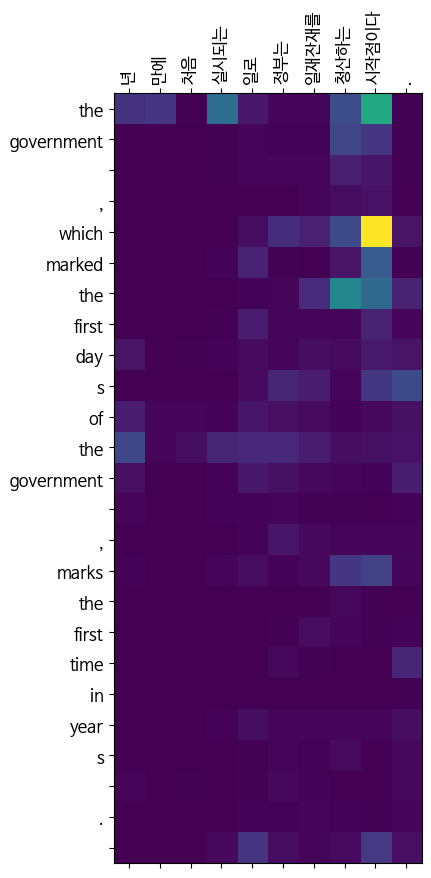

In [115]:
translate(row["source_ko"], model, encoder_tokenizer, decoder_tokenizer)

In [105]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

**결과**
- BLEU는 n-gram 일치도 (0~100)
  - 2.625
  - 정답 문장과 단어 패턴이 거의 겹치지 않는 상태
  - 가장 높은 점수는 29
- BERTScore는 의미 유사도 (-1~1)
  - precision 0.01
  - recall 0.02
  - f1 0.02
  - 거의 의미적으로도 맞지 않는 문장으로 해석하였음
  - 그러나 BERT f1 score 기준으로 최대 0.55까지 유사한 번역도 존재함.
  - 실제로 의미적으로 반연된 번역문장(0.47/1 이상)도 BLEU 기준에서는 점수가 낮은 경우(8.2/100)가 많음  

**회고**
  - 평가지표를 무엇으로 설정하느냐에 따라 모델의 최적화 방향도 달라진다는 것을 알게되었음
  - 번역문장에서는 단순 사용 단어의 일치도보다 의미 유사도가 그럴듯한 평가지표가 될 수 있음
  - 아직 결과를 보고 어떤 방향으로 코드를 수정해야하는 지는 감이 안잡힘 ..